# Engine Maintenance Prediction Model- Microsoft Azure Data Set

## Setup And Data Loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/"

telemetry   = pd.read_csv(data_path + "PdM_telemetry.csv")
errors      = pd.read_csv(data_path + "PdM_errors.csv")
maintenance = pd.read_csv(data_path + "PdM_maint.csv")
failures    = pd.read_csv(data_path + "PdM_failures.csv")
machines    = pd.read_csv(data_path + "PdM_machines.csv")

print("telemetry:  ", telemetry.shape)
print("errors:     ", errors.shape)
print("maintenance:", maintenance.shape)
print("failures:   ", failures.shape)
print("machines:   ", machines.shape)





telemetry:   (876100, 6)
errors:      (3919, 3)
maintenance: (3286, 3)
failures:    (761, 3)
machines:    (100, 3)


##  Data Analysis

In [33]:
for name, df in[( "telemetry", telemetry ),("errors", errors),("maintenance", maintenance),(" faliures", failures),(" machines", machines)]:
    print(f"/n{'='*50}")
    print(f"f{name.upper()}")
    print(df.head(3))
    print(f"/nColumns:{list(df.columns)}")
    print(f"Shape:{df.shape}")

/n==================================================
fTELEMETRY
              datetime  machineID        volt      rotate    pressure  \
0  2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1  2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2  2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  
/nColumns:['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration']
Shape:(876100, 6)
/n==================================================
fERRORS
              datetime  machineID errorID
0  2015-01-03 07:00:00          1  error1
1  2015-01-03 20:00:00          1  error3
2  2015-01-04 06:00:00          1  error5
/nColumns:['datetime', 'machineID', 'errorID']
Shape:(3919, 3)
/n==================================================
fMAINTENANCE
              datetime  machineID   comp
0  2014-06-01 06:00:00          1  comp2
1  2014-07-16 06:00:00          1  comp4
2  20

### Understanding the Data Type And Finding Missing Values

In [34]:
for name, df in [("telemetry", telemetry), ("errors", errors),
                 ("maintenance", maintenance), ("failures", failures),
                 ("machines", machines)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()} — dtypes and nulls")
    print(f"{'='*50}")
    print(df.dtypes)
    print(f"\nMissing values:\n{df.isnull().sum()}")


  TELEMETRY — dtypes and nulls
datetime         str
machineID      int64
volt         float64
rotate       float64
pressure     float64
vibration    float64
dtype: object

Missing values:
datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

  ERRORS — dtypes and nulls
datetime       str
machineID    int64
errorID        str
dtype: object

Missing values:
datetime     0
machineID    0
errorID      0
dtype: int64

  MAINTENANCE — dtypes and nulls
datetime       str
machineID    int64
comp           str
dtype: object

Missing values:
datetime     0
machineID    0
comp         0
dtype: int64

  FAILURES — dtypes and nulls
datetime       str
machineID    int64
failure        str
dtype: object

Missing values:
datetime     0
machineID    0
failure      0
dtype: int64

  MACHINES — dtypes and nulls
machineID    int64
model          str
age          int64
dtype: object

Missing values:
machineID    0
model        0
age          0
dtype: int64

In [35]:
telemetry['datetime']= pd.to_datetime(telemetry['datetime'])
errors['datetime']= pd.to_datetime(errors['datetime'])
failures['datetime']= pd.to_datetime(failures['datetime'])
maintenance['datetime']= pd.to_datetime(maintenance['datetime'])
master = telemetry.merge(errors, on=['machineID', 'datetime'], how='left')
master = master.merge(maintenance, on=['machineID', 'datetime'], how='left')
master = master.merge(failures, on=['machineID', 'datetime'], how='left')
master = master.merge(machines, on='machineID', how='left')
print("master table shape", master.shape)
print("/nColumns",list(master.columns))
print("\nMissing values per column:")
print(master.isnull().sum())
print("\nFirst 3 rows:")
master.head(3)

master table shape (877209, 11)
/nColumns ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'failure', 'model', 'age']

Missing values per column:
datetime          0
machineID         0
volt              0
rotate            0
pressure          0
vibration         0
errorID      873285
comp         874241
failure      876087
model             0
age               0
dtype: int64

First 3 rows:


,datetime,machineID,volt,rotate,pressure,vibration,errorID,comp,failure,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,NaN,NaN,NaN,model3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,NaN,NaN,NaN,model3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,NaN,NaN,NaN,model3,18


In [36]:
# Check how many duplicate rows we have
duplicates = master.duplicated(subset=['machineID', 'datetime']).sum()
print("Duplicate machineID + datetime combinations:", duplicates)

# The extra rows come from hours where multiple events happened at once
# For example machine 1 had error1 AND error2 logged at the same timestamp
# The merge created one row per event instead of one row per hour

# Fix: keep only the first occurrence of each machineID + datetime pair
master = master.drop_duplicates(subset=['machineID', 'datetime'], keep='first')

# Confirm we are back to the correct number of rows
print("Shape after deduplication:", master.shape)
print("Expected: (876100, 11)")


Duplicate machineID + datetime combinations: 1109
Shape after deduplication: (876100, 11)
Expected: (876100, 11)


## Labeling The Data

In [37]:


failure_windows = failures[['machineID', 'datetime']].copy()
failure_windows = failure_windows.rename(columns={'datetime': 'next_failure_dt'})
failure_windows = failure_windows.sort_values(['machineID', 'next_failure_dt']).reset_index(drop=True)

print("failure_windows shape:", failure_windows.shape)
print(failure_windows.head(3))

failure_windows shape: (761, 2)
   machineID     next_failure_dt
0          1 2015-01-05 06:00:00
1          1 2015-03-06 06:00:00
2          1 2015-04-20 06:00:00


In [38]:
import numpy as np

master = master.sort_values('datetime').reset_index(drop=True)
failure_windows = failure_windows.sort_values('next_failure_dt').reset_index(drop=True)

results = []

for machine_id in master['machineID'].unique():
    m_rows     = master[master['machineID'] == machine_id].copy()
    m_failures = failure_windows[failure_windows['machineID'] == machine_id].copy()

    if len(m_failures) == 0:
        m_rows['label'] = 0
        results.append(m_rows)
        continue

    merged = pd.merge_asof(
        m_rows.sort_values('datetime'),
        m_failures[['next_failure_dt']].sort_values('next_failure_dt'),
        left_on='datetime',
        right_on='next_failure_dt',
        direction='forward'
    )

    merged['hours_to_failure'] = (
        merged['next_failure_dt'] - merged['datetime']
    ).dt.total_seconds() / 3600

    merged['label'] = 0
    merged.loc[merged['hours_to_failure'] <= 168, 'label'] = 1
    merged.loc[merged['hours_to_failure'] <= 24,  'label'] = 2
    merged.loc[merged['hours_to_failure'] == 0,   'label'] = 3

    merged = merged.drop(columns=['next_failure_dt', 'hours_to_failure'])
    results.append(merged)

master = pd.concat(results).sort_values(['machineID', 'datetime']).reset_index(drop=True)

print("Shape:", master.shape)
print("\nLabel distribution:")
print(master['label'].value_counts().sort_index())

Shape: (876100, 12)

Label distribution:
label
0    758354
1     99844
2     17183
3       719
Name: count, dtype: int64


In [39]:
print("Shape:", master.shape)
print("\nColumn dtypes:")
print(master.dtypes)
print("\nMissing values:")
print(master.isnull().sum())
print("\nLabel counts:")
print(master['label'].value_counts().sort_index())
print("\nSample row:")
master.sample(1, random_state=42)

Shape: (876100, 12)

Column dtypes:
datetime     datetime64[us]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
errorID                 str
comp                    str
failure                 str
model                   str
age                   int64
label                 int64
dtype: object

Missing values:
datetime          0
machineID         0
volt              0
rotate            0
pressure          0
vibration         0
errorID      872484
comp         873937
failure      875381
model             0
age               0
label             0
dtype: int64

Label counts:
label
0    758354
1     99844
2     17183
3       719
Name: count, dtype: int64

Sample row:


,datetime,machineID,volt,rotate,pressure,vibration,errorID,comp,failure,model,age,label
339238,2015-09-21 14:00:00,39,204.897711,481.23981,97.635401,46.43273,NaN,NaN,NaN,model4,0,0


## Exploratory Data Analysis

### Failure Frequency by Component

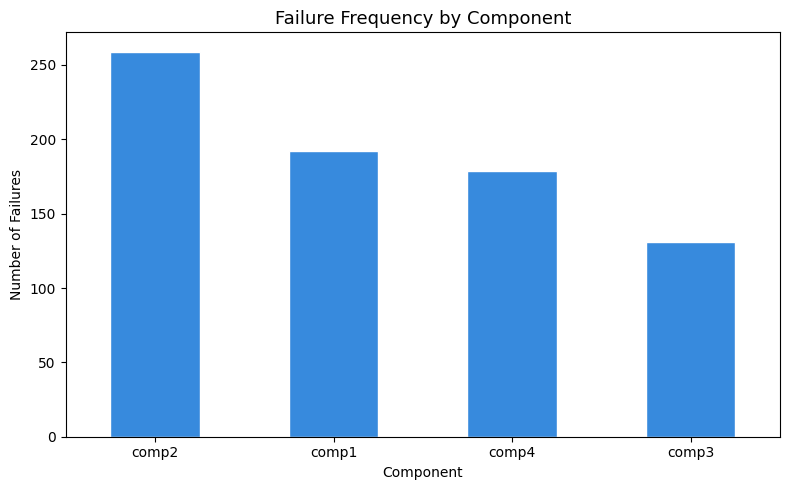

In [84]:
failures['failure'].value_counts().sort_values(ascending=False).plot.bar(
    figsize=(8, 5),
    color='#378ADD',
    edgecolor='white'
)
plt.title('Failure Frequency by Component', fontsize=13)
plt.xlabel('Component')
plt.ylabel('Number of Failures')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###  Sensor Trends Leading up to Failure

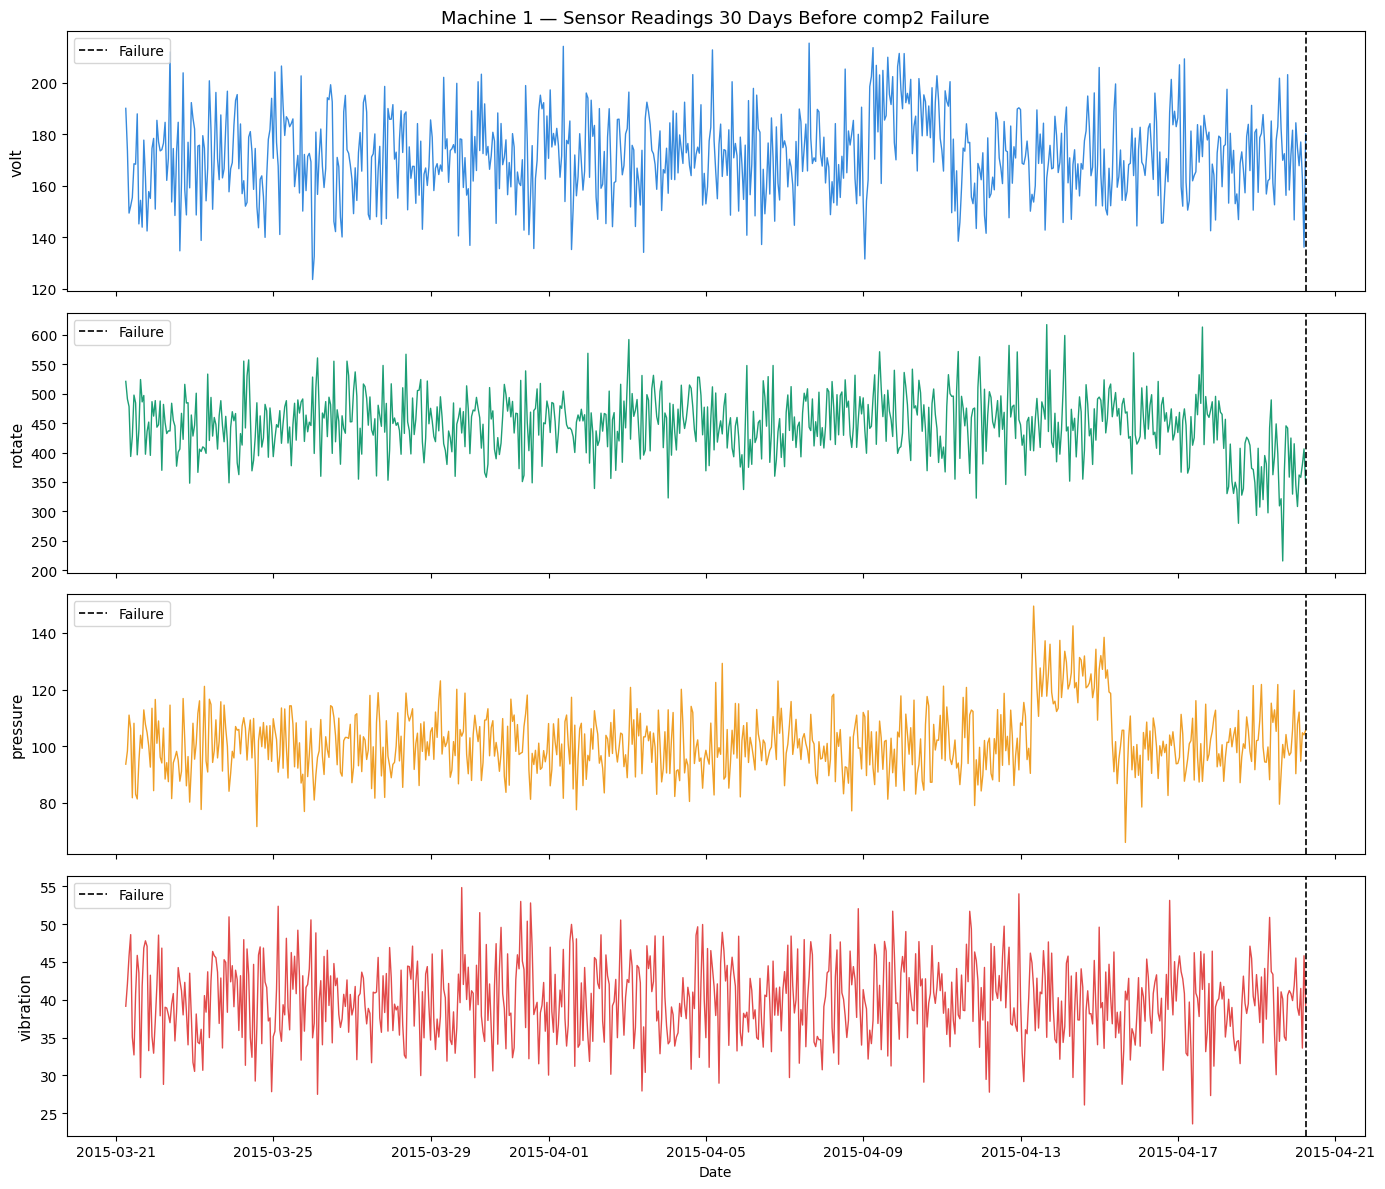

In [85]:
machine_id = 1
comp = 'comp2'

failure_dates = failures[
    (failures['machineID'] == machine_id) &
    (failures['failure'] == comp)
]['datetime'].values

failure_date = pd.Timestamp(failure_dates[0])
window_start = failure_date - pd.Timedelta(days=30)

mask = (
    (telemetry['machineID'] == machine_id) &
    (telemetry['datetime'] >= window_start) &
    (telemetry['datetime'] <= failure_date)
)
machine_data = telemetry[mask].sort_values('datetime')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
sensors = ['volt', 'rotate', 'pressure', 'vibration']
colors = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']

for ax, sensor, color in zip(axes, sensors, colors):
    ax.plot(machine_data['datetime'], machine_data[sensor], color=color, linewidth=1)
    ax.axvline(failure_date, color='black', linestyle='--', linewidth=1.2, label='Failure')
    ax.set_ylabel(sensor, fontsize=11)
    ax.legend(loc='upper left')

axes[0].set_title(f'Machine {machine_id} — Sensor Readings 30 Days Before {comp} Failure', fontsize=13)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

### Sensor distributions by condition class

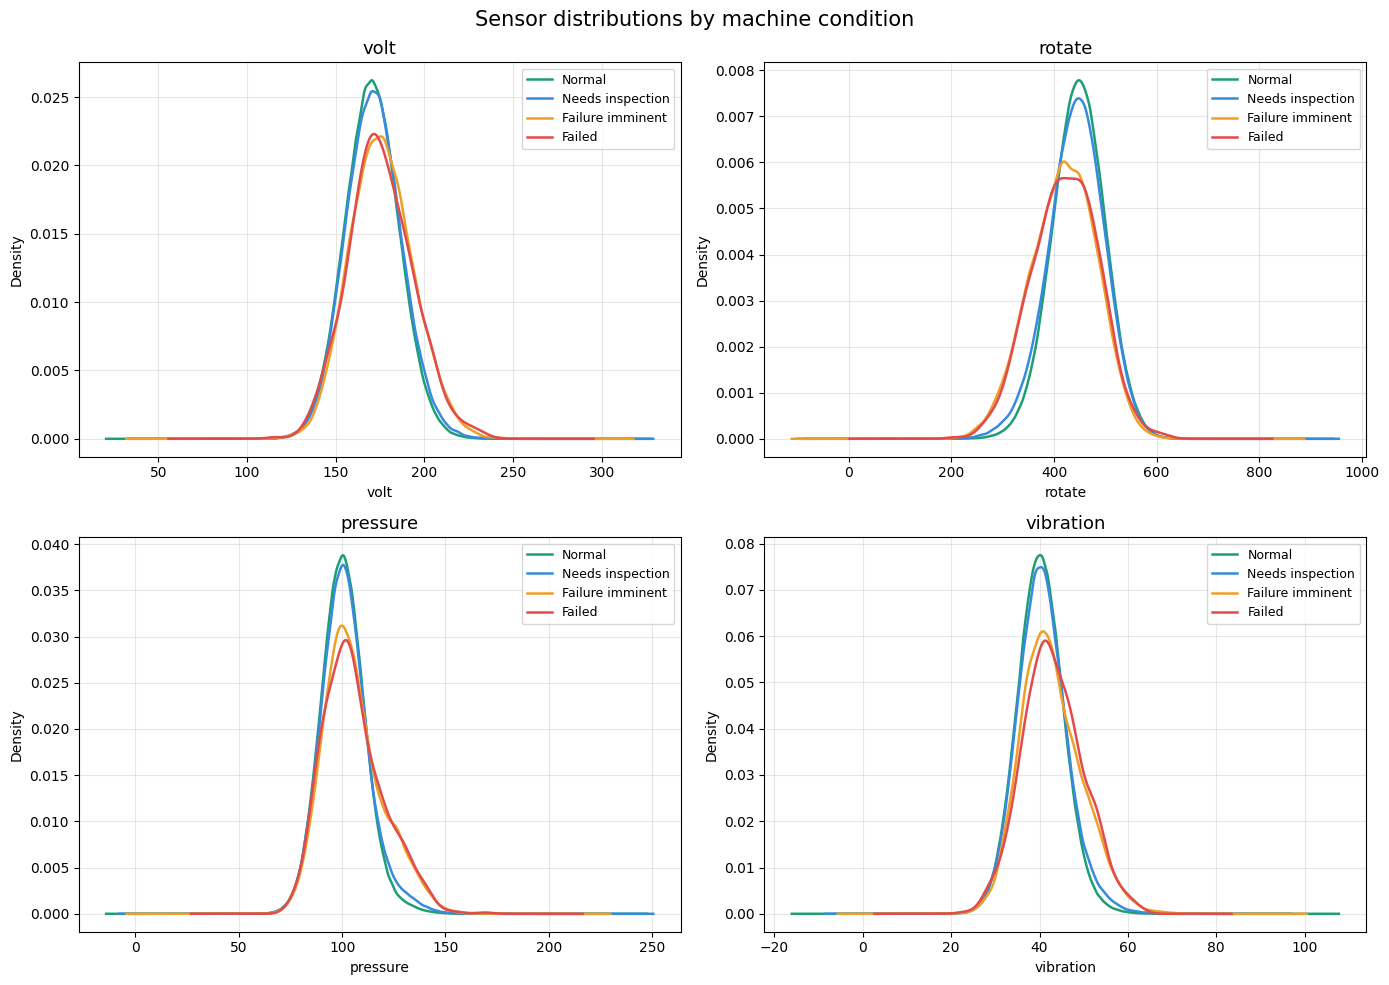

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sensors = ['volt', 'rotate', 'pressure', 'vibration']

label_names = {0: 'Normal', 1: 'Needs inspection',
               2: 'Failure imminent', 3: 'Failed'}
colors = {0: '#1D9E75', 1: '#378ADD', 2: '#EF9F27', 3: '#E24B4A'}

for ax, sensor in zip(axes.flatten(), sensors):
    for label_val, label_name in label_names.items():
        subset = master[master['label'] == label_val][sensor]
        subset.plot.kde(ax=ax, label=label_name,
                        color=colors[label_val], linewidth=1.8)

    ax.set_title(sensor, fontsize=13)
    ax.set_xlabel(sensor)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor distributions by machine condition', fontsize=15)
plt.tight_layout()
plt.show()

### Failures by machine model and age

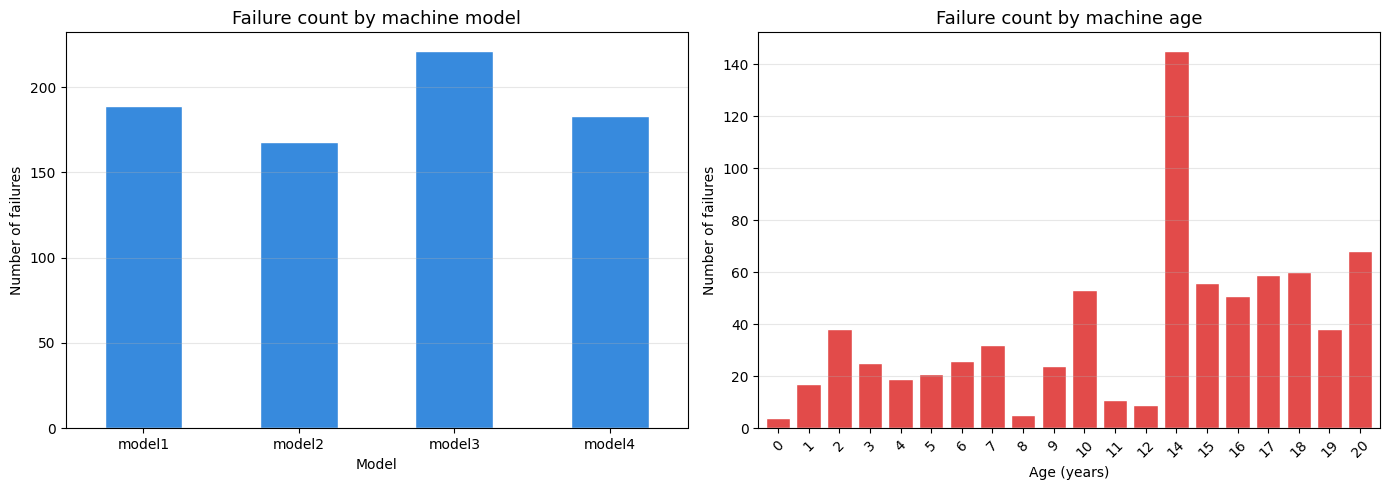

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
failures_merged = failures.merge(machines, on='machineID')
failures_merged.groupby('model')['failure'].count().plot.bar(
    ax=axes[0], color='#378ADD', edgecolor='white'
)
axes[0].set_title('Failure count by machine model', fontsize=13)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Number of failures')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)
failures_merged.groupby('age')['failure'].count().plot.bar(
    ax=axes[1], color='#E24B4A', edgecolor='white', width=0.8
)
axes[1].set_title('Failure count by machine age', fontsize=13)
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Number of failures')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Engineering

### Rolling Statistics on Sensor Readings

In [42]:
master = master.sort_values(['machineID', 'datetime']).reset_index(drop=True)
sensors = ['volt', 'rotate', 'pressure', 'vibration']
windows = [3, 24, 168]
for window in windows:
    for sensor in sensors:
        master[f'{sensor}_mean_{window}h'] = (
            master.groupby('machineID')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        master[f'{sensor}_std_{window}h'] = (
            master.groupby('machineID')[sensor]
            .transform(lambda x: x.rolling(window, min_periods=1).std())
        )

print("Shape after rolling features:", master.shape)
print("\nNew columns added:")
new_cols = [c for c in master.columns if any(f'_{w}h' in c for w in ['3', '24', '168'])]
print(new_cols)


Shape after rolling features: (876100, 36)

New columns added:
['volt_mean_3h', 'volt_std_3h', 'rotate_mean_3h', 'rotate_std_3h', 'pressure_mean_3h', 'pressure_std_3h', 'vibration_mean_3h', 'vibration_std_3h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_mean_168h', 'volt_std_168h', 'rotate_mean_168h', 'rotate_std_168h', 'pressure_mean_168h', 'pressure_std_168h', 'vibration_mean_168h', 'vibration_std_168h']


In [43]:
master = master.loc[:, ~master.columns.duplicated()]
print("Shape after deduplication:", master.shape)
print("Columns:", list(master.columns))


Shape after deduplication: (876100, 36)
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'failure', 'model', 'age', 'label', 'volt_mean_3h', 'volt_std_3h', 'rotate_mean_3h', 'rotate_std_3h', 'pressure_mean_3h', 'pressure_std_3h', 'vibration_mean_3h', 'vibration_std_3h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_mean_168h', 'volt_std_168h', 'rotate_mean_168h', 'rotate_std_168h', 'pressure_mean_168h', 'pressure_std_168h', 'vibration_mean_168h', 'vibration_std_168h']


In [44]:

old_cols = [c for c in master.columns 
            if any(c.endswith(f'{w}h') and f'_{w}h' not in c 
                   for w in ['3', '24', '168'])]

print("Dropping these old columns:", old_cols)
master = master.drop(columns=old_cols)

print("\nShape after cleanup:", master.shape)
print("Columns:", list(master.columns))


Dropping these old columns: []

Shape after cleanup: (876100, 36)
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'failure', 'model', 'age', 'label', 'volt_mean_3h', 'volt_std_3h', 'rotate_mean_3h', 'rotate_std_3h', 'pressure_mean_3h', 'pressure_std_3h', 'vibration_mean_3h', 'vibration_std_3h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_mean_168h', 'volt_std_168h', 'rotate_mean_168h', 'rotate_std_168h', 'pressure_mean_168h', 'pressure_std_168h', 'vibration_mean_168h', 'vibration_std_168h']


In [45]:
# Drop any error columns already in master from a previous run
cols_to_drop = [c for c in master.columns if c.startswith('error')]
master = master.drop(columns=cols_to_drop)
print("Dropped:", cols_to_drop)
print("Shape after drop:", master.shape)

Dropped: ['errorID']
Shape after drop: (876100, 35)


### Errorcount Faliures

In [46]:
# --- Error count features ---
error_dummies = pd.get_dummies(errors.set_index(['machineID', 'datetime'])['errorID'])
error_dummies = error_dummies.reset_index()
error_dummies = error_dummies.groupby(['machineID', 'datetime']).sum().reset_index()

master = master.merge(error_dummies, on=['machineID', 'datetime'], how='left')
error_cols = [c for c in error_dummies.columns if c not in ['machineID', 'datetime']]
master[error_cols] = master[error_cols].fillna(0)

for col in error_cols:
    for window in [24, 168]:
        master[f'{col}_count_{window}h'] = (
            master.groupby('machineID')[col]
            .transform(lambda x: x.rolling(window, min_periods=1).sum())
        )

# --- Time since last maintenance (per machine loop) ---
for comp in ['comp1', 'comp2', 'comp3', 'comp4']:
    comp_maint = maintenance[maintenance['comp'] == comp][['machineID', 'datetime']].copy()
    comp_maint = comp_maint.rename(columns={'datetime': f'last_{comp}'})
    comp_maint[f'last_{comp}'] = pd.to_datetime(comp_maint[f'last_{comp}'])

    results = []
    for machine_id in master['machineID'].unique():
        m_rows  = master[master['machineID'] == machine_id].copy()
        m_maint = comp_maint[comp_maint['machineID'] == machine_id][[f'last_{comp}']].copy()

        m_rows  = m_rows.sort_values('datetime')
        m_maint = m_maint.sort_values(f'last_{comp}')

        if len(m_maint) == 0:
            m_rows[f'hours_since_{comp}'] = 9999
            results.append(m_rows)
            continue

        merged = pd.merge_asof(
            m_rows,
            m_maint,
            left_on='datetime',
            right_on=f'last_{comp}',
            direction='backward'
        )

        merged[f'hours_since_{comp}'] = (
            merged['datetime'] - merged[f'last_{comp}']
        ).dt.total_seconds() / 3600
        merged[f'hours_since_{comp}'] = merged[f'hours_since_{comp}'].fillna(9999)
        merged = merged.drop(columns=[f'last_{comp}'])
        results.append(merged)

    master = pd.concat(results).sort_values(['machineID', 'datetime']).reset_index(drop=True)
    print(f"Done: {comp}")

print("\nShape:", master.shape)
new_cols = [c for c in master.columns if 'count' in c or 'hours_since' in c]
print("New feature columns:", new_cols)

Done: comp1
Done: comp2
Done: comp3
Done: comp4

Shape: (876100, 54)
New feature columns: ['error1_count_24h', 'error1_count_168h', 'error2_count_24h', 'error2_count_168h', 'error3_count_24h', 'error3_count_168h', 'error4_count_24h', 'error4_count_168h', 'error5_count_24h', 'error5_count_168h', 'hours_since_comp1', 'hours_since_comp2', 'hours_since_comp3', 'hours_since_comp4']


In [47]:
save_path = "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/master_table.parquet"
master.to_parquet(save_path, index=False)
print(f"Saved: {master.shape}")


Saved: (876100, 54)


In [48]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

# Load master table
master = pd.read_parquet(
    "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/master_table.parquet"
)

# Encode model column
le = LabelEncoder()
master['model_encoded'] = le.fit_transform(master['model'])

# Define feature columns
drop_cols = ['datetime', 'machineID', 'comp', 'failure', 'label',
             'model', 'error1', 'error2', 'error3', 'error4', 'error5']
feature_cols = [c for c in master.columns if c not in drop_cols]

# Time-based split
cutoff = '2015-10-01'
train = master[master['datetime'] < cutoff]
test  = master[master['datetime'] >= cutoff]

X_train = train[feature_cols]
y_train = train['label']
X_test  = test[feature_cols]
y_test  = test['label']

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Features: 44
Train: (654600, 44) | Test: (221500, 44)


## Model Training

### Train/Test Split and Feature Selection

In [49]:
#
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
master = pd.read_parquet(
    "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/master_table.parquet"
)

le = LabelEncoder()
master['model_encoded'] = le.fit_transform(master['model'])
drop_cols = ['datetime', 'machineID', 'comp', 'failure', 'label',
             'model', 'error1', 'error2', 'error3', 'error4', 'error5']
feature_cols = [c for c in master.columns if c not in drop_cols]
train = master[master['datetime'] < cutoff]
test  = master[master['datetime'] >= cutoff]

X_train = train[feature_cols]
y_train = train['label']
X_test  = test[feature_cols]
y_test  = test['label']
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest label distribution:")
print(y_test.value_counts().sort_index())

Features: 44
Train: (654600, 44) | Test: (221500, 44)

Train label distribution:
label
0    564175
1     76744
2     13133
3       548
Name: count, dtype: int64

Test label distribution:
label
0    194179
1     23100
2      4050
3       171
Name: count, dtype: int64


### XGBoost Baseline Model

In [50]:
# Train XGBClassifier
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained successfully")


Model trained successfully


In [51]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Classification report — shows precision, recall and F1 for each class
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.92      0.97      0.94    194179
Needs Inspection       0.54      0.30      0.39     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.69      0.58      0.63       171

        accuracy                           0.90    221500
       macro avg       0.79      0.71      0.74    221500
    weighted avg       0.88      0.90      0.89    221500



### Class Distribution Check

In [52]:
print("Training label distribution:")
print(y_train.value_counts().sort_index())
print()
print("As percentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

Training label distribution:
label
0    564175
1     76744
2     13133
3       548
Name: count, dtype: int64

As percentages:
label
0    86.19
1    11.72
2     2.01
3     0.08
Name: proportion, dtype: float64


In [53]:
from sklearn.utils.class_weight import compute_sample_weight

# compute_sample_weight calculates a weight for every single row in the
# training set. Rows belonging to rare classes get higher weights.
# 'balanced' means it automatically computes weights as:
# total_samples / (n_classes * samples_in_this_class)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Sample weight stats per class:")
for label in sorted(y_train.unique()):
    w = sample_weights[y_train == label][0]
    count = (y_train == label).sum()
    print(f"  Class {label}: count={count:>7,}  weight={w:.2f}")

Sample weight stats per class:
  Class 0: count=564,175  weight=0.29
  Class 1: count= 76,744  weight=2.13
  Class 2: count= 13,133  weight=12.46
  Class 3: count=    548  weight=298.63


In [54]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# sample_weight tells the model how much to penalise mistakes on each row
# Rare class rows have high weights so the model is forced to learn them
model.fit(X_train, y_train, sample_weight=sample_weights)
print("Model retrained with class weights successfully")


Model retrained with class weights successfully


In [55]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.97      0.80      0.88    194179
Needs Inspection       0.33      0.81      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.33      0.93      0.48       171

        accuracy                           0.81    221500
       macro avg       0.65      0.88      0.71    221500
    weighted avg       0.90      0.81      0.84    221500



In [56]:
best_model_xgb = xgb.XGBClassifier(
    subsample=1.0,
    n_estimators=100,
    min_child_weight=10,
    max_depth=4,
    learning_rate=0.1,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

best_model_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = best_model_xgb.predict(X_test)

print("Tuned XGBoost — Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

Tuned XGBoost — Classification Report:
                  precision    recall  f1-score   support

          Normal       0.99      0.70      0.82    194179
Needs Inspection       0.27      0.93      0.42     23100
Failure Imminent       0.98      1.00      0.99      4050
          Failed       0.15      0.99      0.25       171

        accuracy                           0.73    221500
       macro avg       0.60      0.90      0.62    221500
    weighted avg       0.91      0.73      0.78    221500



In [57]:
best_model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

best_model_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = best_model_xgb.predict(X_test)

print("XGBoost baseline — Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

XGBoost baseline — Classification Report:
                  precision    recall  f1-score   support

          Normal       0.97      0.80      0.88    194179
Needs Inspection       0.33      0.81      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.33      0.93      0.48       171

        accuracy                           0.81    221500
       macro avg       0.65      0.88      0.71    221500
    weighted avg       0.90      0.81      0.84    221500



In [58]:
import joblib

model_path = "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/xgb_baseline.pkl"
joblib.dump(best_model_xgb, model_path)
print(f"Saved: {model_path}")

Saved: /Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/xgb_baseline.pkl


### Training on LightGBM 

In [59]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [60]:
model_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    min_child_samples=20,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_lgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_lgb = model_lgb.predict(X_test)

print("LightGBM — Classification Report:")
print(classification_report(y_test, y_pred_lgb,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

LightGBM — Classification Report:
                  precision    recall  f1-score   support

          Normal       0.96      0.83      0.89    194179
Needs Inspection       0.34      0.74      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.96      1.00      0.98       171

        accuracy                           0.83    221500
       macro avg       0.81      0.89      0.83    221500
    weighted avg       0.90      0.83      0.85    221500



In [61]:
lgb_path = "/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/lgb_baseline.pkl"
joblib.dump(model_lgb, lgb_path)
print(f"Saved: {lgb_path}")

Saved: /Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/lgb_baseline.pkl


In [62]:

y_proba = model_lgb.predict_proba(X_test)

print("Probability array shape:", y_proba.shape)
print("\nFirst 3 rows (prob for each of 4 classes):")
print(y_proba[:3].round(3))
print("\nColumns = [Normal, Needs Inspection, Failure Imminent, Failed]")

Probability array shape: (221500, 4)

First 3 rows (prob for each of 4 classes):
[[0.846 0.154 0.    0.   ]
 [0.836 0.164 0.    0.   ]
 [0.844 0.156 0.    0.   ]]

Columns = [Normal, Needs Inspection, Failure Imminent, Failed]


## Threshold Tuning

### Threshold Function Definition

In [63]:
import numpy as np

def predict_with_thresholds(proba, thresholds):
    # thresholds is a list of 4 values, one per class
    # For each row, check if any class exceeds its threshold
    # Priority goes to higher classes (3 > 2 > 1 > 0)
    n_rows = proba.shape[0]
    preds = np.zeros(n_rows, dtype=int)
    
    for i in range(n_rows):
        # Check from highest class downward
        predicted = 0
        for cls in [3, 2, 1]:
            if proba[i, cls] >= thresholds[cls]:
                predicted = cls
                break
        preds[i] = predicted
    
    return preds

# Start with default thresholds — same as standard predict()
# Then raise class 1 threshold to reduce its false alarms
thresholds = [0.5, 0.6, 0.5, 0.5]

y_pred_tuned = predict_with_thresholds(y_proba, thresholds)

print("Tuned LightGBM — Classification Report:")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

Tuned LightGBM — Classification Report:
                  precision    recall  f1-score   support

          Normal       0.95      0.87      0.91    194179
Needs Inspection       0.37      0.64      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.96      1.00      0.98       171

        accuracy                           0.85    221500
       macro avg       0.82      0.88      0.84    221500
    weighted avg       0.89      0.85      0.87    221500



### Threshold Tuning for Class 1 

In [64]:
for threshold in [0.65, 0.70, 0.75, 0.80]:
    thresholds = [0.5, threshold, 0.5, 0.5]
    y_pred_tuned = predict_with_thresholds(y_proba, thresholds)
    from sklearn.metrics import f1_score, precision_score, recall_score
    p = precision_score(y_test, y_pred_tuned, average=None)[1]
    r = recall_score(y_test, y_pred_tuned, average=None)[1]
    f = f1_score(y_test, y_pred_tuned, average='macro')
    print(f"Threshold {threshold:.2f} | Class 1 precision={p:.2f}  recall={r:.2f} | Macro F1={f:.2f}")

Threshold 0.65 | Class 1 precision=0.39  recall=0.58 | Macro F1=0.84
Threshold 0.70 | Class 1 precision=0.42  recall=0.52 | Macro F1=0.84
Threshold 0.75 | Class 1 precision=0.44  recall=0.44 | Macro F1=0.84
Threshold 0.80 | Class 1 precision=0.48  recall=0.36 | Macro F1=0.83


### Final Threshold Tuned Model

In [65]:
# Final model with chosen threshold
final_thresholds = [0.5, 0.70, 0.5, 0.5]
y_pred_final = predict_with_thresholds(y_proba, final_thresholds)

print("Final LightGBM — Classification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

Final LightGBM — Classification Report:
                  precision    recall  f1-score   support

          Normal       0.94      0.91      0.93    194179
Needs Inspection       0.42      0.52      0.46     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       0.96      1.00      0.98       171

        accuracy                           0.87    221500
       macro avg       0.83      0.86      0.84    221500
    weighted avg       0.89      0.87      0.88    221500



## Feature Engineering — Failure History

In [66]:
print(failures.shape)
print(failures['failure'].value_counts())
print()
print(failures.head(5))

(761, 3)
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

             datetime  machineID failure
0 2015-01-05 06:00:00          1   comp4
1 2015-03-06 06:00:00          1   comp1
2 2015-04-20 06:00:00          1   comp2
3 2015-06-19 06:00:00          1   comp4
4 2015-09-02 06:00:00          1   comp4


###  Hours Since Last Component Failure

In [67]:
for comp in ['comp1', 'comp2', 'comp3', 'comp4']:
    comp_failures = failures[failures['failure'] == comp][['machineID', 'datetime']].copy()
    comp_failures = comp_failures.rename(columns={'datetime': f'last_{comp}_failure'})
    comp_failures[f'last_{comp}_failure'] = pd.to_datetime(comp_failures[f'last_{comp}_failure'])

    results = []
    for machine_id in master['machineID'].unique():
        m_rows = master[master['machineID'] == machine_id].copy()
        m_fail = comp_failures[comp_failures['machineID'] == machine_id][[f'last_{comp}_failure']].copy()

        m_rows = m_rows.sort_values('datetime')
        m_fail = m_fail.sort_values(f'last_{comp}_failure')

        if len(m_fail) == 0:
            m_rows[f'hours_since_{comp}_failure'] = 9999
            results.append(m_rows)
            continue

        merged = pd.merge_asof(
            m_rows,
            m_fail,
            left_on='datetime',
            right_on=f'last_{comp}_failure',
            direction='backward'
        )

        merged[f'hours_since_{comp}_failure'] = (
            merged['datetime'] - merged[f'last_{comp}_failure']
        ).dt.total_seconds() / 3600
        merged[f'hours_since_{comp}_failure'] = merged[f'hours_since_{comp}_failure'].fillna(9999)
        merged = merged.drop(columns=[f'last_{comp}_failure'])
        results.append(merged)

    master = pd.concat(results).sort_values(['machineID', 'datetime']).reset_index(drop=True)
    print(f"Done: {comp}")

print("\nShape:", master.shape)
print("New columns:", [c for c in master.columns if 'failure' in c and 'hours' in c])


Done: comp1
Done: comp2
Done: comp3
Done: comp4

Shape: (876100, 59)
New columns: ['hours_since_comp1_failure', 'hours_since_comp2_failure', 'hours_since_comp3_failure', 'hours_since_comp4_failure']


In [68]:
print(master.shape)
print(master.columns.tolist())

(876100, 59)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'comp', 'failure', 'model', 'age', 'label', 'volt_mean_3h', 'volt_std_3h', 'rotate_mean_3h', 'rotate_std_3h', 'pressure_mean_3h', 'pressure_std_3h', 'vibration_mean_3h', 'vibration_std_3h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_mean_168h', 'volt_std_168h', 'rotate_mean_168h', 'rotate_std_168h', 'pressure_mean_168h', 'pressure_std_168h', 'vibration_mean_168h', 'vibration_std_168h', 'error1', 'error2', 'error3', 'error4', 'error5', 'error1_count_24h', 'error1_count_168h', 'error2_count_24h', 'error2_count_168h', 'error3_count_24h', 'error3_count_168h', 'error4_count_24h', 'error4_count_168h', 'error5_count_24h', 'error5_count_168h', 'hours_since_comp1', 'hours_since_comp2', 'hours_since_comp3', 'hours_since_comp4', 'model_encoded', 'hours_since_comp1_failure', 'hours_since_comp2_failure'

In [69]:
print(master['failure'].value_counts())
print(master['failure'].dtype)

failure
comp2    250
comp1    192
comp4    155
comp3    122
Name: count, dtype: int64
str


###  Rolling Failure Counts (168h)

In [70]:
master = master.sort_values(['machineID', 'datetime']).reset_index(drop=True)

for comp in ['comp1', 'comp2', 'comp3', 'comp4']:
    master[f'{comp}_failure_count_168h'] = (
        master.assign(temp=(master['failure'] == comp).astype(int))
        .set_index('datetime')
        .groupby('machineID')['temp']
        .transform(lambda x: x.rolling('168h').sum())
        .values
    )
print(master.shape)
print(master[['comp1_failure_count_168h','comp2_failure_count_168h','comp3_failure_count_168h','comp4_failure_count_168h']].describe())

(876100, 63)
       comp1_failure_count_168h  comp2_failure_count_168h  \
count             876100.000000             876100.000000   
mean                   0.036031                  0.047751   
std                    0.186368                  0.213240   
min                    0.000000                  0.000000   
25%                    0.000000                  0.000000   
50%                    0.000000                  0.000000   
75%                    0.000000                  0.000000   
max                    1.000000                  1.000000   

       comp3_failure_count_168h  comp4_failure_count_168h  
count             876100.000000             876100.000000  
mean                   0.023286                  0.029235  
std                    0.150811                  0.168465  
min                    0.000000                  0.000000  
25%                    0.000000                  0.000000  
50%                    0.000000                  0.000000  
75%              

In [71]:
master.to_parquet('/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/master_table.parquet', index=False)
print("Saved.")

Saved.


In [72]:
print(master['label'].value_counts().sort_index())
print(master['label'].value_counts(normalize=True).sort_index().round(4))

label
0    758354
1     99844
2     17183
3       719
Name: count, dtype: int64
label
0    0.8656
1    0.1140
2    0.0196
3    0.0008
Name: proportion, dtype: float64


## Retraining with Failure History Features

### Training with Class Distribution

In [73]:
drop_cols = ['datetime', 'machineID', 'label', 'comp', 'failure', 'model']

X = master.drop(columns=drop_cols)
y = master['label']
cutoff = pd.Timestamp('2015-10-01')

train_mask = master['datetime'] < cutoff
test_mask  = master['datetime'] >= cutoff

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

import numpy as np

total = len(y_train)
n_classes = 4
class_counts = y_train.value_counts().sort_index()

weights_map = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(weights_map).values

print("Class weights:")
for cls, w in weights_map.items():
    print(f"  Class {cls}: {w:.2f}")

Train: (654600, 57), Test: (221500, 57)
label
0    564175
1     76744
2     13133
3       548
Name: count, dtype: int64
label
0    194179
1     23100
2      4050
3       171
Name: count, dtype: int64
Class weights:
  Class 0: 0.29
  Class 1: 2.13
  Class 2: 12.46
  Class 3: 298.63


In [74]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print("Training complete.")
print(f"Best iteration: {lgb_model.best_iteration_}")

[100]	valid_0's multi_logloss: 0.312015
[200]	valid_0's multi_logloss: 0.29186
[300]	valid_0's multi_logloss: 0.288143
Training complete.
Best iteration: 285


### Threshold Retuning

In [75]:
from sklearn.metrics import classification_report
import numpy as np

final_thresholds = [0.5, 0.70, 0.5, 0.5]

def predict_with_thresholds(proba, thresholds):
    n_rows = proba.shape[0]
    preds = np.zeros(n_rows, dtype=int)
    for i in range(n_rows):
        predicted = 0
        for cls in [3, 2, 1]:
            if proba[i, cls] >= thresholds[cls]:
                predicted = cls
                break
        preds[i] = predicted
    return preds

proba = lgb_model.predict_proba(X_test)
preds = predict_with_thresholds(proba, final_thresholds)

print("Thresholds applied:", final_thresholds)
print(classification_report(y_test, preds, target_names=['Normal','Needs Inspection','Failure Imminent','Failed']))

Thresholds applied: [0.5, 0.7, 0.5, 0.5]
                  precision    recall  f1-score   support

          Normal       0.92      0.95      0.93    194179
Needs Inspection       0.43      0.33      0.37     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       1.00      1.00      1.00       171

        accuracy                           0.88    221500
       macro avg       0.83      0.82      0.83    221500
    weighted avg       0.87      0.88      0.88    221500



In [76]:
for threshold in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    thresholds = [0.5, threshold, 0.5, 0.5]
    preds_tuned = predict_with_thresholds(proba, thresholds)
    from sklearn.metrics import f1_score, precision_score, recall_score
    p = precision_score(y_test, preds_tuned, average=None)[1]
    r = recall_score(y_test, preds_tuned, average=None)[1]
    f = f1_score(y_test, preds_tuned, average='macro')
    print(f"Threshold {threshold:.2f} | Class 1 precision={p:.2f}  recall={r:.2f} | Macro F1={f:.3f}")
    

Threshold 0.40 | Class 1 precision=0.37  recall=0.64 | Macro F1=0.843
Threshold 0.45 | Class 1 precision=0.38  recall=0.60 | Macro F1=0.845
Threshold 0.50 | Class 1 precision=0.40  recall=0.56 | Macro F1=0.845
Threshold 0.55 | Class 1 precision=0.41  recall=0.50 | Macro F1=0.842
Threshold 0.60 | Class 1 precision=0.41  recall=0.44 | Macro F1=0.838
Threshold 0.65 | Class 1 precision=0.42  recall=0.39 | Macro F1=0.833
Threshold 0.70 | Class 1 precision=0.43  recall=0.33 | Macro F1=0.825


In [77]:
final_thresholds = [0.5, 0.45, 0.5, 0.5]
preds_final = predict_with_thresholds(proba, final_thresholds)

print(classification_report(y_test, preds_final,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))
      

                  precision    recall  f1-score   support

          Normal       0.95      0.88      0.92    194179
Needs Inspection       0.38      0.60      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       1.00      1.00      1.00       171

        accuracy                           0.86    221500
       macro avg       0.83      0.87      0.84    221500
    weighted avg       0.89      0.86      0.87    221500



In [78]:
import joblib
import json

lgb_path = '/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/lgb_model_v2.pkl'
thresholds_path = '/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/final_thresholds.json'

joblib.dump(lgb_model, lgb_path)

with open(thresholds_path, 'w') as f:
    json.dump(final_thresholds, f)

print("Model saved:", lgb_path)
print("Thresholds saved:", thresholds_path)

Model saved: /Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/lgb_model_v2.pkl
Thresholds saved: /Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/final_thresholds.json


In [79]:
master = master.drop(columns=['model_encoded'])
master.to_parquet('/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/master_table.parquet', index=False)
print(master.shape)

(876100, 62)


## Retraining Without Model Encoding 

### Final Model

In [80]:
drop_cols = ['datetime', 'machineID', 'label', 'comp', 'failure', 'model']

X = master.drop(columns=drop_cols)
y = master['label']

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

total = len(y_train)
class_counts = y_train.value_counts().sort_index()
weights_map = {cls: total / (4 * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(weights_map).values

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

proba = lgb_model.predict_proba(X_test)
preds_final = predict_with_thresholds(proba, final_thresholds)

print(classification_report(y_test, preds_final,
      target_names=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed']))

[100]	valid_0's multi_logloss: 0.312937
[200]	valid_0's multi_logloss: 0.283281
[300]	valid_0's multi_logloss: 0.281007
                  precision    recall  f1-score   support

          Normal       0.95      0.88      0.92    194179
Needs Inspection       0.38      0.62      0.47     23100
Failure Imminent       0.99      1.00      0.99      4050
          Failed       1.00      1.00      1.00       171

        accuracy                           0.86    221500
       macro avg       0.83      0.87      0.85    221500
    weighted avg       0.89      0.86      0.87    221500



In [81]:
joblib.dump(lgb_model, '/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/lgb_model_v2.pkl')
print("Saved.")

Saved.


## Model Evaluation And Interpretaion

### Confusion Matrix

In [82]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, preds_final)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Normal', 'Actual: Needs Inspection', 'Actual: Failure Imminent', 'Actual: Failed'],
    columns=['Pred: Normal', 'Pred: Needs Inspection', 'Pred: Failure Imminent', 'Pred: Failed']
)

print(cm_df)

                          Pred: Normal  Pred: Needs Inspection  \
Actual: Normal                  171218                   22926   
Actual: Needs Inspection          8807                   14288   
Actual: Failure Imminent             5                       5   
Actual: Failed                       0                       0   

                          Pred: Failure Imminent  Pred: Failed  
Actual: Normal                                35             0  
Actual: Needs Inspection                       5             0  
Actual: Failure Imminent                    4040             0  
Actual: Failed                                 0           171  


### Feature Importance graph

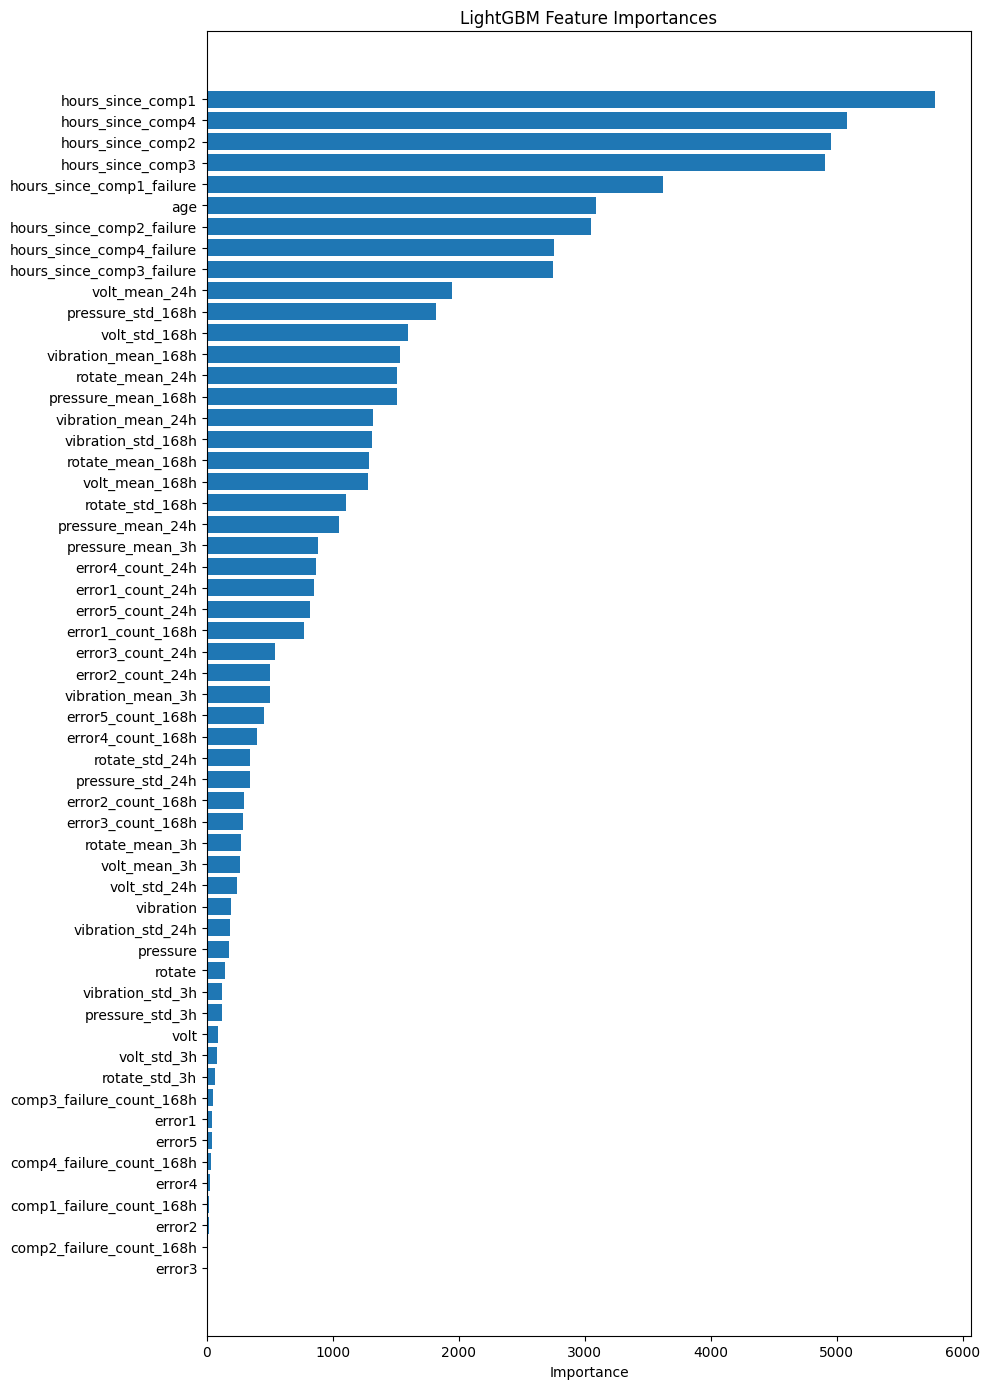

Saved.


In [83]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()
importances = pd.Series(lgb_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 14))
plt.barh(importances.index, importances.values)
plt.xlabel('Importance')
plt.title('LightGBM Feature Importances')
plt.tight_layout()
plt.savefig('/Users/adharvaturaga/Documents/Code/Engine Maitanence ML/Microsoft Azure/feature_importance.png', dpi=150)
plt.show()
print("Saved.")

### Confusion Matrix Heatmap

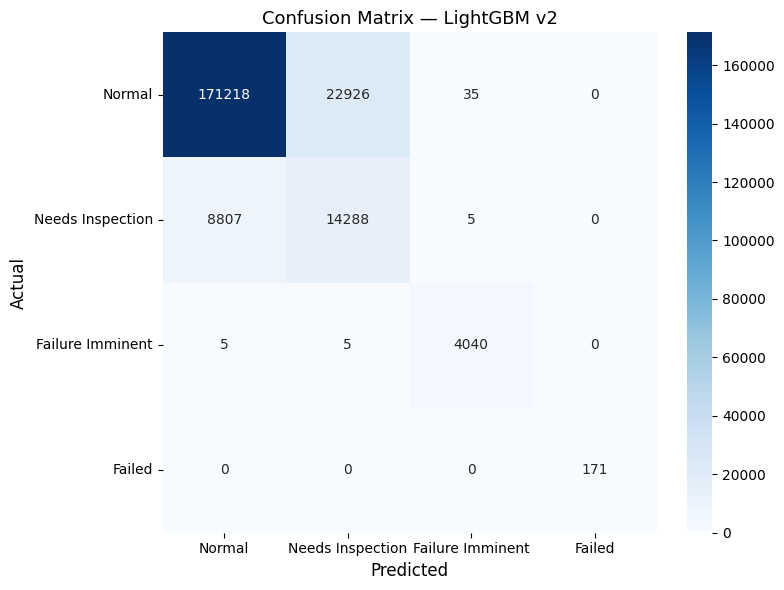

In [86]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed'],
    yticklabels=['Normal', 'Needs Inspection', 'Failure Imminent', 'Failed'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — LightGBM v2', fontsize=13)
plt.tight_layout()
plt.show()